In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_FILE = (
    PROJECT_ROOT / "data" / "processed" / "medicare_claims.sqlite"
)

if not DATABASE_FILE.exists():
    raise FileNotFoundError(DATABASE_FILE)

print("Database:", DATABASE_FILE)

Database: d:\projects\Medicare Claims Analytics\data\processed\medicare_claims.sqlite


In [2]:
query = """
SELECT
    CLM_ID,
    BENE_ID,
    SERVICE_YEAR,
    CLM_DRG_CD,
    CLM_PMT_AMT,
    LENGTH_OF_STAY_DAYS,
    CLM_UTLZTN_DAY_CNT
FROM inpatient_claim
WHERE SERVICE_YEAR BETWEEN 2016 AND 2022
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    drg_claims = pd.read_sql_query(query, connection)

# DRG 是分类代码，保留字符串类型
drg_claims["CLM_DRG_CD"] = (
    drg_claims["CLM_DRG_CD"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

display(drg_claims.head())

display(pd.DataFrame({
    "check": [
        "Claims",
        "Unique DRG codes",
        "Missing DRG codes",
        "Duplicate claim IDs",
    ],
    "count": [
        len(drg_claims),
        drg_claims["CLM_DRG_CD"].nunique(),
        drg_claims["CLM_DRG_CD"].isna().sum(),
        drg_claims["CLM_ID"].duplicated().sum(),
    ],
}))

,CLM_ID,BENE_ID,SERVICE_YEAR,CLM_DRG_CD,CLM_PMT_AMT,LENGTH_OF_STAY_DAYS,CLM_UTLZTN_DAY_CNT
0,-10000930038031,-10000010254653,2017,923,8545.72,1,1
1,-10000930038162,-10000010254656,2017,564,1014.85,0,0
2,-10000930038163,-10000010254656,2018,951,9911.41,0,0
3,-10000930038164,-10000010254656,2022,951,2962.04,0,0
4,-10000930038442,-10000010254682,2021,963,12044.66,0,0


,check,count
0,Claims,18631
1,Unique DRG codes,166
2,Missing DRG codes,2435
3,Duplicate claim IDs,0


In [3]:
# 新建分析分组字段，保留原始 DRG 字段
drg_claims["drg_group"] = (
    drg_claims["CLM_DRG_CD"].fillna("Missing")
)

drg_summary = (
    drg_claims.groupby("drg_group")
    .agg(
        claim_count=("CLM_ID", "size"),
        beneficiary_count=("BENE_ID", "nunique"),
        total_payment=("CLM_PMT_AMT", "sum"),
        mean_payment=("CLM_PMT_AMT", "mean"),
        median_payment=("CLM_PMT_AMT", "median"),
        mean_date_span_days=("LENGTH_OF_STAY_DAYS", "mean"),
    )
    .reset_index()
)

drg_summary["payment_share_percent"] = (
    drg_summary["total_payment"]
    / drg_claims["CLM_PMT_AMT"].sum()
    * 100
)

drg_summary = drg_summary.sort_values(
    "total_payment",
    ascending=False,
)

display(drg_summary.head(15).round(2))

print("Claims after grouping:", drg_summary["claim_count"].sum())
print(
    "Payment share total:",
    round(drg_summary["payment_share_percent"].sum(), 2),
)

,drg_group,claim_count,beneficiary_count,total_payment,mean_payment,median_payment,mean_date_span_days,payment_share_percent
159,951,7083,1940,30560721.03,4314.66,1215.28,0.62,24.23
29,181,70,18,6431729.69,91881.85,78491.87,6.46,5.10
28,180,57,17,6154073.14,107966.20,92952.28,7.39,4.88
30,182,70,17,5632669.70,80466.71,74626.22,5.76,4.47
57,303,97,94,3740622.30,38563.12,24694.71,0.84,2.97
65,314,52,35,3291618.78,63300.36,3786.96,1.23,2.61
56,302,84,82,3082487.91,36696.28,20820.34,0.82,2.44
161,964,381,370,2620877.53,6878.94,7018.34,0.17,2.08
128,791,123,109,2545371.22,20694.07,8961.25,1.37,2.02
160,963,394,387,2498833.99,6342.22,1095.24,0.18,1.98


Claims after grouping: 18631
Payment share total: 100.0


In [4]:
display(
    drg_summary.loc[
        drg_summary["drg_group"].eq("Missing")
    ].round(2)
)

,drg_group,claim_count,beneficiary_count,total_payment,mean_payment,median_payment,mean_date_span_days,payment_share_percent
166,Missing,2435,762,801437.08,329.13,119.83,3.37,0.64


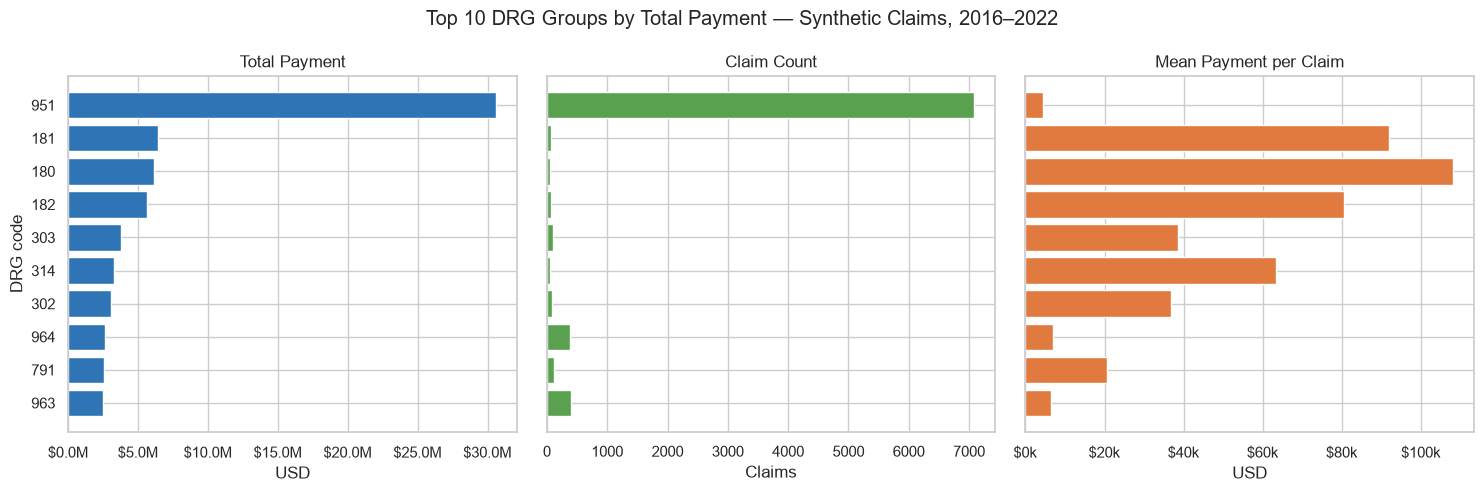

In [5]:
top_drg = (
    drg_summary.head(10)
    .sort_values("total_payment")
    .copy()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

metrics = [
    ("total_payment", "Total Payment", "#2F75B5"),
    ("claim_count", "Claim Count", "#59A14F"),
    ("mean_payment", "Mean Payment per Claim", "#E07A3F"),
]

for ax, (column, title, color) in zip(axes, metrics):
    ax.barh(
        top_drg["drg_group"],
        top_drg[column],
        color=color,
    )
    ax.set_title(title)
    ax.set_xlabel("Claims" if column == "claim_count" else "USD")

axes[0].set_ylabel("DRG code")

axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M")
)

axes[2].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value / 1_000:.0f}k")
)

fig.suptitle(
    "Top 10 DRG Groups by Total Payment — Synthetic Claims, 2016–2022"
)

plt.tight_layout()
plt.show()

In [6]:
drg_year = (
    drg_claims.groupby(["drg_group", "SERVICE_YEAR"])
    .agg(
        claim_count=("CLM_ID", "size"),
        total_payment=("CLM_PMT_AMT", "sum"),
    )
    .reset_index()
)

payment_by_year = drg_year.pivot(
    index="drg_group",
    columns="SERVICE_YEAR",
    values="total_payment",
).fillna(0)

count_by_year = drg_year.pivot(
    index="drg_group",
    columns="SERVICE_YEAR",
    values="claim_count",
).fillna(0)

drg_change = pd.DataFrame({
    "payment_2019": payment_by_year[2019],
    "payment_2020": payment_by_year[2020],
    "claims_2019": count_by_year[2019],
    "claims_2020": count_by_year[2020],
})

drg_change["payment_change"] = (
    drg_change["payment_2020"] - drg_change["payment_2019"]
)

drg_change["claim_count_change"] = (
    drg_change["claims_2020"] - drg_change["claims_2019"]
)

total_change = drg_change["payment_change"].sum()

drg_change["share_of_net_increase_percent"] = (
    drg_change["payment_change"] / total_change * 100
)

drg_change = drg_change.sort_values(
    "payment_change",
    ascending=False,
)

display(drg_change.head(10).round(2))
print(f"Total payment increase: ${total_change:,.2f}")

,payment_2019,payment_2020,claims_2019,claims_2020,payment_change,claim_count_change,share_of_net_increase_percent
drg_group,,,,,,,
951,3759279.06,5141371.42,1014.0,1077.0,1382092.36,63.0,17.35
181,0.00,1234797.62,0.0,11.0,1234797.62,11.0,15.50
180,0.00,986622.42,0.0,10.0,986622.42,10.0,12.38
315,35745.43,876470.84,4.0,9.0,840725.41,5.0,10.55
182,83310.22,864757.94,1.0,12.0,781447.72,11.0,9.81
314,365443.80,1091066.96,3.0,19.0,725623.16,16.0,9.11
204,0.00,381442.34,0.0,16.0,381442.34,16.0,4.79
316,14851.81,380478.96,4.0,10.0,365627.15,6.0,4.59
864,0.00,359854.49,0.0,13.0,359854.49,13.0,4.52


Total payment increase: $7,967,103.54


In [7]:
driver_comparison = drg_change.head(10).copy()

for year in [2019, 2020]:
    # 没有 claim 的年份，平均值保持缺失，不能填成 0
    denominator = driver_comparison[f"claims_{year}"].where(
        driver_comparison[f"claims_{year}"].gt(0)
    )

    driver_comparison[f"mean_payment_{year}"] = (
        driver_comparison[f"payment_{year}"] / denominator
    )

display(
    driver_comparison[
        [
            "claims_2019",
            "claims_2020",
            "mean_payment_2019",
            "mean_payment_2020",
            "payment_change",
            "share_of_net_increase_percent",
        ]
    ].round(2)
)

,claims_2019,claims_2020,mean_payment_2019,mean_payment_2020,payment_change,share_of_net_increase_percent
drg_group,,,,,,
951,1014.0,1077.0,3707.38,4773.79,1382092.36,17.35
181,0.0,11.0,NaN,112254.33,1234797.62,15.50
180,0.0,10.0,NaN,98662.24,986622.42,12.38
315,4.0,9.0,8936.36,97385.65,840725.41,10.55
182,1.0,12.0,83310.22,72063.16,781447.72,9.81
314,3.0,19.0,121814.60,57424.58,725623.16,9.11
204,0.0,16.0,NaN,23840.15,381442.34,4.79
316,4.0,10.0,3712.95,38047.90,365627.15,4.59
864,0.0,13.0,NaN,27681.11,359854.49,4.52


In [8]:
drg_951 = drg_claims.loc[
    drg_claims["drg_group"].eq("951")
    & drg_claims["SERVICE_YEAR"].isin([2019, 2020])
].copy()

drg_951_comparison = (
    drg_951.groupby("SERVICE_YEAR")
    .agg(
        claim_count=("CLM_ID", "size"),
        beneficiary_count=("BENE_ID", "nunique"),
        total_payment=("CLM_PMT_AMT", "sum"),
        mean_payment=("CLM_PMT_AMT", "mean"),
        median_payment=("CLM_PMT_AMT", "median"),
        p90_payment=(
            "CLM_PMT_AMT",
            lambda values: values.quantile(0.90),
        ),
        p99_payment=(
            "CLM_PMT_AMT",
            lambda values: values.quantile(0.99),
        ),
        max_payment=("CLM_PMT_AMT", "max"),
    )
)

display(drg_951_comparison.round(2))

,claim_count,beneficiary_count,total_payment,mean_payment,median_payment,p90_payment,p99_payment,max_payment
SERVICE_YEAR,,,,,,,,
2019,1014,411,3759279.06,3707.38,1238.68,7681.51,53421.55,144001.74
2020,1077,465,5141371.42,4773.79,1251.76,10391.44,77882.77,142779.16


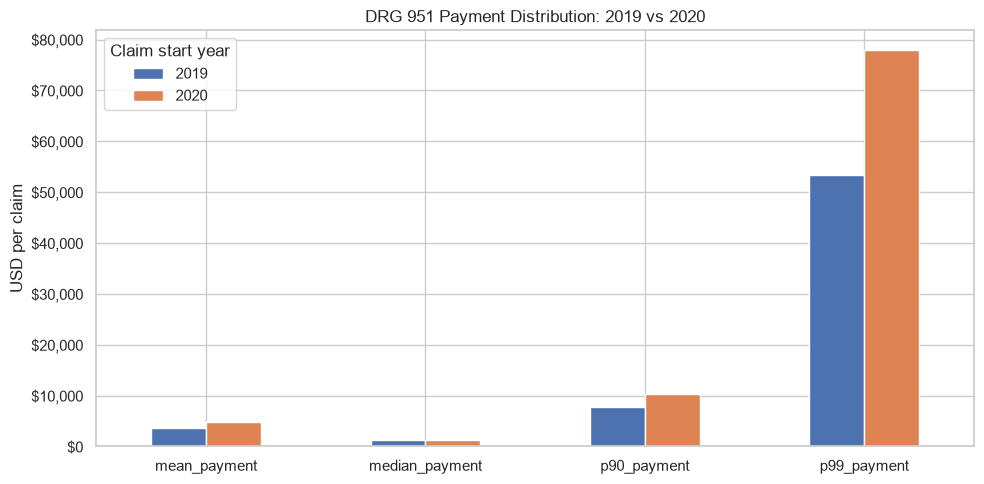

In [9]:
ax = drg_951_comparison[
    ["mean_payment", "median_payment", "p90_payment", "p99_payment"]
].T.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("DRG 951 Payment Distribution: 2019 vs 2020")
ax.set_xlabel("")
ax.set_ylabel("USD per claim")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value:,.0f}")
)
ax.legend(title="Claim start year")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
threshold = drg_951.loc[
    drg_951["SERVICE_YEAR"].eq(2019),
    "CLM_PMT_AMT",
].quantile(0.90)

tail_data = drg_951.copy()

tail_data["payment_band"] = "At or below threshold"
tail_data.loc[
    tail_data["CLM_PMT_AMT"].gt(threshold),
    "payment_band",
] = "Above threshold"

tail_summary = (
    tail_data.groupby(["SERVICE_YEAR", "payment_band"])
    .agg(
        claim_count=("CLM_ID", "size"),
        total_payment=("CLM_PMT_AMT", "sum"),
        mean_payment=("CLM_PMT_AMT", "mean"),
    )
    .reset_index()
)

tail_summary["claim_share_percent"] = (
    tail_summary["claim_count"]
    / tail_summary.groupby("SERVICE_YEAR")["claim_count"]
      .transform("sum")
    * 100
)

tail_summary["payment_share_percent"] = (
    tail_summary["total_payment"]
    / tail_summary.groupby("SERVICE_YEAR")["total_payment"]
      .transform("sum")
    * 100
)

print(f"Fixed threshold: ${threshold:,.2f}")
display(tail_summary.round(2))

Fixed threshold: $7,681.51


,SERVICE_YEAR,payment_band,claim_count,total_payment,mean_payment,claim_share_percent,payment_share_percent
0,2019,Above threshold,102,2507639.91,24584.70,10.06,66.71
1,2019,At or below threshold,912,1251639.15,1372.41,89.94,33.29
2,2020,Above threshold,135,3739465.64,27699.75,12.53,72.73
3,2020,At or below threshold,942,1401905.78,1488.22,87.47,27.27


In [11]:
band_change = tail_summary.pivot(
    index="payment_band",
    columns="SERVICE_YEAR",
    values="total_payment",
)

band_change["payment_increase"] = (
    band_change[2020] - band_change[2019]
)

band_change["share_of_increase_percent"] = (
    band_change["payment_increase"]
    / band_change["payment_increase"].sum()
    * 100
)

display(band_change.round(2))

print(
    "DRG 951 total increase:",
    f"${band_change['payment_increase'].sum():,.2f}",
)

SERVICE_YEAR,2019,2020,payment_increase,share_of_increase_percent
payment_band,,,,
Above threshold,2507639.91,3739465.64,1231825.73,89.13
At or below threshold,1251639.15,1401905.78,150266.63,10.87


DRG 951 total increase: $1,382,092.36


In [12]:
band_change = tail_summary.pivot(
    index="payment_band",
    columns="SERVICE_YEAR",
    values="total_payment",
)

band_change["payment_increase"] = (
    band_change[2020] - band_change[2019]
)

band_change["share_of_increase_percent"] = (
    band_change["payment_increase"]
    / band_change["payment_increase"].sum()
    * 100
)

display(band_change.round(2))

print(
    "DRG 951 total increase:",
    f"${band_change['payment_increase'].sum():,.2f}",
)

SERVICE_YEAR,2019,2020,payment_increase,share_of_increase_percent
payment_band,,,,
Above threshold,2507639.91,3739465.64,1231825.73,89.13
At or below threshold,1251639.15,1401905.78,150266.63,10.87


DRG 951 total increase: $1,382,092.36


## DRG 951 payment growth: 2019–2020

Claim count increased by approximately 6.2%, while mean payment
increased by 28.8%. Median payment changed by only 1.1%.

Using the 2019 P90 payment ($7,681.51) as a fixed threshold,
claims above this threshold contributed approximately 89.13%
of the group's total payment increase.

Both the count and average payment of above-threshold claims increased.
This is a descriptive finding in synthetic data; the underlying
clinical or payment mechanism has not been established.

In [13]:
drg_reference = pd.DataFrame({
    "drg_group": ["951", "180", "181", "182"],
    "reference_description": [
        "Other factors influencing health status",
        "Respiratory neoplasms with MCC",
        "Respiratory neoplasms with CC",
        "Respiratory neoplasms without CC/MCC",
    ],
    "reference_version": ["MS-DRG v37.0"] * 4,
    "source_url": [
        "https://www.cms.gov/icd10m/version37-fullcode-cms/fullcode_cms/P0026.html",
        *[
            "https://www.cms.gov/icd10m/version37-fullcode-cms/fullcode_cms/P0007.html"
        ] * 3,
    ],
})

display(drg_reference)

,drg_group,reference_description,reference_version,source_url
0,951,Other factors influencing health status,MS-DRG v37.0,https://www.cms.gov/icd10m/version37-fullcode-...
1,180,Respiratory neoplasms with MCC,MS-DRG v37.0,https://www.cms.gov/icd10m/version37-fullcode-...
2,181,Respiratory neoplasms with CC,MS-DRG v37.0,https://www.cms.gov/icd10m/version37-fullcode-...
3,182,Respiratory neoplasms without CC/MCC,MS-DRG v37.0,https://www.cms.gov/icd10m/version37-fullcode-...


In [15]:
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

drg_summary_labeled = drg_summary.merge(
    drg_reference,
    on="drg_group",
    how="left",
    validate="one_to_one",
)

display(
    drg_summary_labeled.loc[
        drg_summary_labeled["reference_description"].notna(),
        [
            "drg_group",
            "reference_description",
            "reference_version",
            "claim_count",
            "total_payment",
            "mean_payment",
        ],
    ].round(2)
)

drg_reference.to_csv(
    PROJECT_ROOT / "docs" / "drg_reference_v37_partial.csv",
    index=False,
)

drg_summary_labeled.to_csv(
    REPORT_DIR / "inpatient_drg_summary_labeled.csv",
    index=False,
)

,drg_group,reference_description,reference_version,claim_count,total_payment,mean_payment
0,951,Other factors influencing health status,MS-DRG v37.0,7083,30560721.03,4314.66
1,181,Respiratory neoplasms with CC,MS-DRG v37.0,70,6431729.69,91881.85
2,180,Respiratory neoplasms with MCC,MS-DRG v37.0,57,6154073.14,107966.20
3,182,Respiratory neoplasms without CC/MCC,MS-DRG v37.0,70,5632669.70,80466.71


In [16]:
diagnosis_query = """
SELECT
    CLM_ID,
    BENE_ID,
    SERVICE_YEAR,
    PRNCPAL_DGNS_CD,
    CLM_PMT_AMT
FROM inpatient_claim
WHERE SERVICE_YEAR BETWEEN 2016 AND 2022
  AND TRIM(CLM_DRG_CD) = '951'
"""

with sqlite3.connect(DATABASE_FILE) as connection:
    drg951_diagnoses = pd.read_sql_query(
        diagnosis_query,
        connection,
    )

drg951_diagnoses["diagnosis_group"] = (
    drg951_diagnoses["PRNCPAL_DGNS_CD"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
    .fillna("Missing")
)

diagnosis_summary = (
    drg951_diagnoses.groupby("diagnosis_group")
    .agg(
        claim_count=("CLM_ID", "size"),
        total_payment=("CLM_PMT_AMT", "sum"),
        mean_payment=("CLM_PMT_AMT", "mean"),
        median_payment=("CLM_PMT_AMT", "median"),
    )
    .reset_index()
)

diagnosis_summary["claim_share_percent"] = (
    diagnosis_summary["claim_count"]
    / len(drg951_diagnoses)
    * 100
)

diagnosis_summary["payment_share_percent"] = (
    diagnosis_summary["total_payment"]
    / drg951_diagnoses["CLM_PMT_AMT"].sum()
    * 100
)

display(
    diagnosis_summary
    .sort_values("claim_count", ascending=False)
    .head(10)
    .round(2)
)

print("Total DRG 951 claims:", diagnosis_summary["claim_count"].sum())

,diagnosis_group,claim_count,total_payment,mean_payment,median_payment,claim_share_percent,payment_share_percent
5,Z733,2685,6452558.91,2403.19,1001.63,37.91,21.11
3,Z608,1725,3530166.24,2046.47,982.01,24.35,11.55
2,Z604,801,1126611.19,1406.51,983.71,11.31,3.69
9,Z951,499,8019557.73,16071.26,2572.26,7.05,26.24
6,Z7682,413,1840701.81,4456.91,3425.70,5.83,6.02
0,Z3400,329,1870063.12,5684.08,4957.91,4.64,6.12
1,Z3480,304,1703914.75,5604.98,4840.34,4.29,5.58
10,Z95818,249,5608101.27,22522.50,7298.08,3.52,18.35
4,Z653,59,96076.40,1628.41,1072.00,0.83,0.31
11,Z98890,9,33136.31,3681.81,1814.59,0.13,0.11


Total DRG 951 claims: 7083


In [17]:
display(
    diagnosis_summary
    .sort_values("total_payment", ascending=False)
    .head(10)
    .round(2)
)

,diagnosis_group,claim_count,total_payment,mean_payment,median_payment,claim_share_percent,payment_share_percent
9,Z951,499,8019557.73,16071.26,2572.26,7.05,26.24
5,Z733,2685,6452558.91,2403.19,1001.63,37.91,21.11
10,Z95818,249,5608101.27,22522.50,7298.08,3.52,18.35
3,Z608,1725,3530166.24,2046.47,982.01,24.35,11.55
0,Z3400,329,1870063.12,5684.08,4957.91,4.64,6.12
6,Z7682,413,1840701.81,4456.91,3425.70,5.83,6.02
1,Z3480,304,1703914.75,5604.98,4840.34,4.29,5.58
2,Z604,801,1126611.19,1406.51,983.71,11.31,3.69
7,Z89439,6,141455.98,23576.00,21615.02,0.08,0.46
8,Z899,4,138377.32,34594.33,35177.88,0.06,0.45


In [18]:
diagnosis_year = (
    drg951_diagnoses.loc[
        drg951_diagnoses["SERVICE_YEAR"].isin([2019, 2020])
    ]
    .groupby(["diagnosis_group", "SERVICE_YEAR"])
    .agg(
        claim_count=("CLM_ID", "size"),
        total_payment=("CLM_PMT_AMT", "sum"),
    )
    .reset_index()
)

diagnosis_payments = diagnosis_year.pivot(
    index="diagnosis_group",
    columns="SERVICE_YEAR",
    values="total_payment",
).reindex(columns=[2019, 2020], fill_value=0).fillna(0)

diagnosis_counts = diagnosis_year.pivot(
    index="diagnosis_group",
    columns="SERVICE_YEAR",
    values="claim_count",
).reindex(columns=[2019, 2020], fill_value=0).fillna(0)

diagnosis_change = pd.DataFrame({
    "claims_2019": diagnosis_counts[2019],
    "claims_2020": diagnosis_counts[2020],
    "payment_2019": diagnosis_payments[2019],
    "payment_2020": diagnosis_payments[2020],
})

diagnosis_change["payment_change"] = (
    diagnosis_change["payment_2020"]
    - diagnosis_change["payment_2019"]
)

diagnosis_change = diagnosis_change.sort_values(
    "payment_change",
    ascending=False,
)

display(diagnosis_change.round(2))

print(
    "Total DRG 951 payment increase:",
    f"${diagnosis_change['payment_change'].sum():,.2f}",
)

,claims_2019,claims_2020,payment_2019,payment_2020,payment_change
diagnosis_group,,,,,
Z951,67.0,97.0,903946.02,1629521.33,725575.31
Z95818,34.0,44.0,866537.64,1216584.13,350046.49
Z3400,41.0,60.0,216847.02,421746.43,204899.41
Z608,227.0,239.0,281633.81,420539.85,138906.04
Z7682,50.0,80.0,265197.11,339694.90,74497.79
Z733,381.0,391.0,631929.42,683488.56,51559.14
Z89439,1.0,1.0,18454.38,17042.11,-1412.27
Z604,140.0,120.0,170821.29,159916.49,-10904.80
Z98890,3.0,0.0,12302.20,0.00,-12302.20


Total DRG 951 payment increase: $1,382,092.36


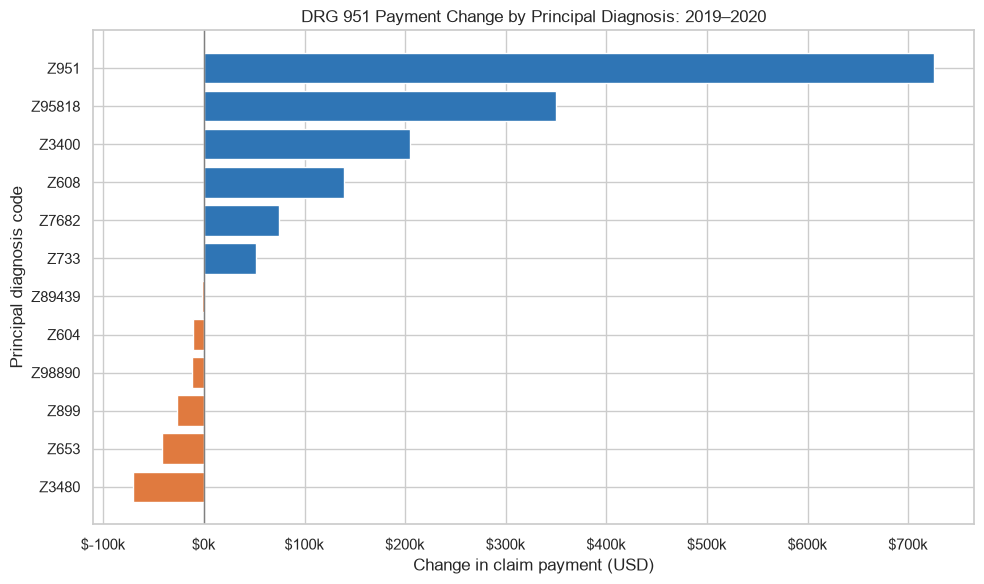

In [19]:
diagnosis_change_plot = diagnosis_change.sort_values(
    "payment_change"
)

colors = [
    "#E07A3F" if value < 0 else "#2F75B5"
    for value in diagnosis_change_plot["payment_change"]
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    diagnosis_change_plot.index.astype(str),
    diagnosis_change_plot["payment_change"],
    color=colors,
)

ax.axvline(0, color="gray", linewidth=1)

ax.set_title(
    "DRG 951 Payment Change by Principal Diagnosis: 2019–2020"
)
ax.set_xlabel("Change in claim payment (USD)")
ax.set_ylabel("Principal diagnosis code")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value / 1000:,.0f}k")
)

plt.tight_layout()
plt.show()

In [20]:
focus_diagnoses = drg951_diagnoses.loc[
    drg951_diagnoses["SERVICE_YEAR"].isin([2019, 2020])
    & drg951_diagnoses["diagnosis_group"].isin(
        ["Z951", "Z95818"]
    )
]

focus_summary = (
    focus_diagnoses
    .groupby(["diagnosis_group", "SERVICE_YEAR"])
    .agg(
        claim_count=("CLM_ID", "size"),
        beneficiary_count=("BENE_ID", "nunique"),
        total_payment=("CLM_PMT_AMT", "sum"),
        mean_payment=("CLM_PMT_AMT", "mean"),
        median_payment=("CLM_PMT_AMT", "median"),
        max_payment=("CLM_PMT_AMT", "max"),
    )
)

display(focus_summary.round(2))

focus_increase = diagnosis_change.loc[
    ["Z951", "Z95818"], "payment_change"
].sum()

print(f"Combined increase: ${focus_increase:,.2f}")
print(
    "Share of DRG 951 net increase:",
    f"{focus_increase / diagnosis_change['payment_change'].sum():.2%}",
)

claim_count  beneficiary_count  total_payment  \
diagnosis_group SERVICE_YEAR                                                  
Z951            2019                   67                 40      903946.02   
                2020                   97                 61     1629521.33   
Z95818          2019                   34                 26      866537.64   
                2020                   44                 35     1216584.13   

                              mean_payment  median_payment  max_payment  
diagnosis_group SERVICE_YEAR                                             
Z951            2019              13491.73         2568.97    144001.74  
                2020              16799.19         2572.26    142779.16  
Z95818          2019              25486.40        10076.62    138470.08  
                2020              27649.64        12925.55    104710.03

Combined increase: $1,075,621.80
Share of DRG 951 net increase: 77.83%


## Final findings and limitations

- DRG 951 payment increased by $1,382,092.36 from 2019 to 2020.
- Median claim payment remained nearly unchanged.
- Claims above the fixed 2019 P90 threshold ($7,681.51)
  contributed 89.13% of the payment increase.
- Principal diagnosis groups Z951 and Z95818 contributed
  $1,075,621.80, or 77.83%, of the net increase.

These are descriptive findings from synthetic data.
Status diagnosis codes do not establish that a procedure occurred
during the claim. Clinical causes and historical DRG version
consistency have not been established.
Claim counts are not independent hospitalization counts.

In [24]:
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

final_outputs = {
    "inpatient_drg951_diagnosis_summary": diagnosis_summary,
    "inpatient_drg951_diagnosis_change": diagnosis_change.reset_index(),
    "inpatient_drg951_focus_diagnoses": focus_summary.reset_index(),
}

for name, result in final_outputs.items():
    result.to_csv(
        REPORT_DIR / f"{name}.csv",
        index=False,
    )

print("Saved 3 final analysis tables.")

Saved 3 final analysis tables.
